# Topic model evaluation 

This nb will look at evaluating the extracted topics, by applying measures of topic diversity and topic coherence. I think I could also calculate a square matrix of cosine similarity between all the topics. 

There are a few resources I followed for this: [https://towardsdatascience.com/understanding-topic-coherence-measures-4aa41339634c/](https://towardsdatascience.com/understanding-topic-coherence-measures-4aa41339634c/)

[https://radimrehurek.com/gensim/models/coherencemodel.html](https://radimrehurek.com/gensim/models/coherencemodel.html)

Some nice graphs of the model performance: [https://towardsdatascience.com/use-metrics-to-determine-lda-topic-model-size-1a1feaa1ff3c/](https://towardsdatascience.com/use-metrics-to-determine-lda-topic-model-size-1a1feaa1ff3c/)

Can use this for pairwise cosine similarity: ```from sklearn.metrics.pairwise import cosine_similarity```

Or I think I may need to use [OCTIS](https://github.com/mind-Lab/octis) package - [BERTopic discussion here](https://github.com/MaartenGr/BERTopic/discussions/627)

In [1]:
# Import necessary packages 
import pandas as pd
import numpy as np

from octis.evaluation_metrics.diversity_metrics import TopicDiversity
from octis.evaluation_metrics.coherence_metrics import Coherence
from sklearn.metrics.pairwise import cosine_similarity

import ast 

import seaborn as sns
import matplotlib.pyplot as plt

from database.comments import Comments
from database.topics import Topics

import sys
sys.path.append('/root/comment_crunch/pipeline')
from nlp_tasks import NLP_Tasks

/opt/conda/envs/nlp_env_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load outputs/topic_model/full_bertopic/object_topics.csv
m1_topics_object = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic/object_topics.csv')
m1_topics_object_embeddings = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic/object_topic_embeddings.csv')

In [3]:
cs_topics = cosine_similarity(m1_topics_object_embeddings, m1_topics_object_embeddings)

In [4]:
cs_topics.shape

(2533, 2533)

In [5]:
cs_topics_reduced = cs_topics[1:21,1:21]

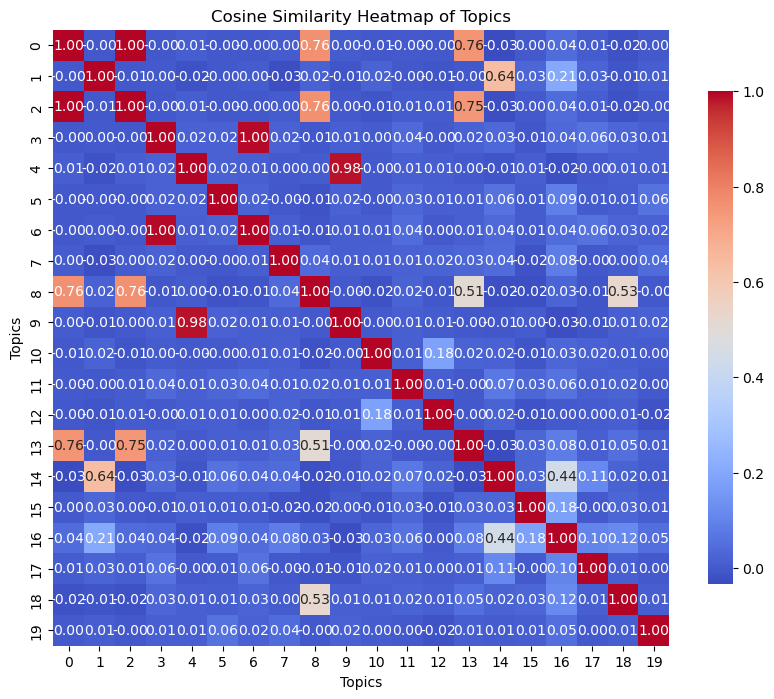

In [6]:
# plot heatmap of cosine similarity
plt.figure(figsize=(10, 8))
sns.heatmap(cs_topics_reduced, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Cosine Similarity Heatmap of Topics')
plt.xlabel('Topics')
plt.ylabel('Topics')
plt.show()

### Topic diveristy score for the full model (with the fine-tuned sentence transformer)

In [7]:
# Load and parse support topics
topics_full_model_object = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic/object_topics.csv')
object_topics = [ast.literal_eval(item) for item in topics_full_model_object['Representation'].tolist()]

# Load and parse support topics
topics_full_model_support = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic/supports_topics.csv')
support_topics = [ast.literal_eval(item) for item in topics_full_model_support['Representation'].tolist()]

# Load and parse neutral topics
topics_full_model_neutral = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic/neutral_topics.csv')
neutral_topics = [ast.literal_eval(item) for item in topics_full_model_neutral['Representation'].tolist()]


In [8]:
metric = TopicDiversity(topk=3) # Initialize metric

# object
topic_div_score_full_object = metric.score({'topics':object_topics})
print(f"Topic Diversity Score for object topics: {topic_div_score_full_object}")

# support
topic_diversity_score_full_support = metric.score({'topics':support_topics})
print(f"Topic Diversity Score (Support): {topic_diversity_score_full_support}")

# neutral
topic_diversity_score_full_neutral = metric.score({'topics':neutral_topics})
print(f"Topic Diversity Score (Neutral): {topic_diversity_score_full_neutral}")

Topic Diversity Score for object topics: 0.6079747335175681
Topic Diversity Score (Support): 0.7325349301397206
Topic Diversity Score (Neutral): 0.7913486005089059


In [9]:
# object
# Initialize coherence metric
coh_metric = Coherence(texts=object_topics, topk=10, measure='c_npmi')  # or 'c_v', etc.
# Score the topics
topic_coh_score_full_object = coh_metric.score({'topics': object_topics})
print(f"Topic Coherence Score (object): {topic_coh_score_full_object:.4f}")

# support
# Initialize coherence metric
coh_metric = Coherence(texts=support_topics, topk=10, measure='c_npmi')  # or 'c_v', etc.
# Score the topics
topic_coh_score_full_support = coh_metric.score({'topics': support_topics})
print(f"Topic Coherence Score (support): {topic_coh_score_full_support:.4f}")   

# neutral
# Initialize coherence metric
coh_metric = Coherence(texts=neutral_topics, topk=10, measure='c_npmi')  # or 'c_v', etc.
# Score the topics
topic_coh_score_full_neutral = coh_metric.score({'topics': neutral_topics})
print(f"Topic Coherence Score (neutral): {topic_coh_score_full_neutral:.4f}")

Topic Coherence Score (object): 0.7317
Topic Coherence Score (support): 0.8026
Topic Coherence Score (neutral): 0.8263


In [10]:
# Function to compute diversity score over growing topic sets
def compute_diversity_scores(topic_list, label, metric):
    num_topics = range(1, len(topic_list) + 1)
    scores = []
    for i in range(len(topic_list)):
        partial = topic_list[:i+1]
        score = metric.score({'topics': partial})
        scores.append(score)
    return pd.DataFrame({
        'num_topics': num_topics,
        'diversity_score': scores,
        'topic_type': label
    })

# Compute diversity scores
metric = TopicDiversity(topk=3)

df_object = compute_diversity_scores(object_topics, 'object', metric)
df_support = compute_diversity_scores(support_topics, 'support', metric)
df_neutral = compute_diversity_scores(neutral_topics, 'neutral', metric)

# Combine all into one DataFrame
df_all = pd.concat([df_object, df_support, df_neutral], ignore_index=True)

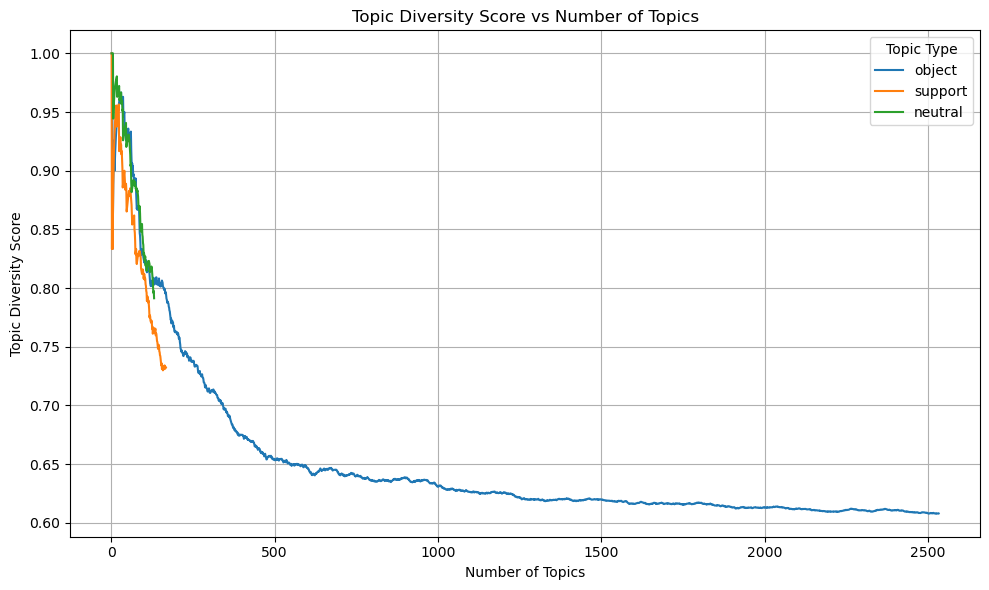

In [11]:
# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_all, x='num_topics', y='diversity_score', hue='topic_type')
plt.title('Topic Diversity Score vs Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Topic Diversity Score')
plt.grid(True)
plt.legend(title='Topic Type')
plt.tight_layout()
plt.show()

### Note: this currently takes a very long time to run - I think this is the wrong thing. 

In [14]:
# function to compute coherence score over growing topic sets
def compute_coherence_scores(topic_list, label, metric):
    num_topics = range(1, len(topic_list) + 1)
    scores = []
    for i in range(len(topic_list)):
        partial = topic_list[:i+1]
        score = metric.score({'topics': partial})
        scores.append(score)
    return pd.DataFrame({
        'num_topics': num_topics,
        'coherence_score': scores,
        'topic_type': label
    })
# Compute coherence scores
coh_metric = Coherence(texts=object_topics, topk=5, measure='c_npmi')  # or 'c_v', etc.
df_object_coh = compute_coherence_scores(object_topics, 'object', coh_metric)
coh_metric = Coherence(texts=support_topics, topk=5, measure='c_npmi')  # or 'c_v', etc.
df_support_coh = compute_coherence_scores(support_topics, 'support', coh_metric)
coh_metric = Coherence(texts=neutral_topics, topk=5, measure='c_npmi')  # or 'c_v', etc.
df_neutral_coh = compute_coherence_scores(neutral_topics, 'neutral', coh_metric)    

# Combine all coherence scores into one DataFrame
df_all_coh = pd.concat([df_object_coh, df_support_coh, df_neutral_coh], ignore_index=True)

KeyboardInterrupt: 

### Topic diveristy score for the full model (with the baseline sentence transformer)

In [ ]:
# Load and parse support topics
topics_baseline_model_object = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic_baseline_st/object_topics.csv')
object_topics_baseline = [ast.literal_eval(item) for item in topics_baseline_model_object['Representation'].tolist()]

# Load and parse support topics
topics_baseline_model_support = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic_baseline_st/supports_topics.csv')
support_topics_baseline = [ast.literal_eval(item) for item in topics_baseline_model_support['Representation'].tolist()]

# Load and parse neutral topics
topics_baseline_model_neutral = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic_baseline_st/neutral_topics.csv')
neutral_topics_baseline = [ast.literal_eval(item) for item in topics_baseline_model_neutral['Representation'].tolist()]

In [ ]:
metric = TopicDiversity(topk=3) # Initialize metric

# object
topic_div_score_baseline_object = metric.score({'topics':object_topics_baseline})
print(f"Topic Diversity Score for object topics (Baseline): {topic_div_score_baseline_object}")

# support
topic_diversity_score_baseline_support = metric.score({'topics':support_topics_baseline})
print(f"Topic Diversity Score (Support, Baseline): {topic_diversity_score_baseline_support}")

# neutral
topic_diversity_score_baseline_neutral = metric.score({'topics':neutral_topics_baseline})
print(f"Topic Diversity Score (Neutral, Baseline): {topic_diversity_score_baseline_neutral}")

Topic Diversity Score for object topics (Baseline): 0.6559466019417476
Topic Diversity Score (Support, Baseline): 0.8063725490196079
Topic Diversity Score (Neutral, Baseline): 0.8803418803418803


In [ ]:
df_object_baseline = compute_diversity_scores(object_topics_baseline, 'object', metric)
df_support_baseline = compute_diversity_scores(support_topics_baseline, 'support', metric)
df_neutral_baseline = compute_diversity_scores(neutral_topics_baseline, 'neutral', metric)

# Combine all into one DataFrame
df_all_baseline = pd.concat([df_object_baseline, df_support_baseline, df_neutral_baseline], ignore_index=True)

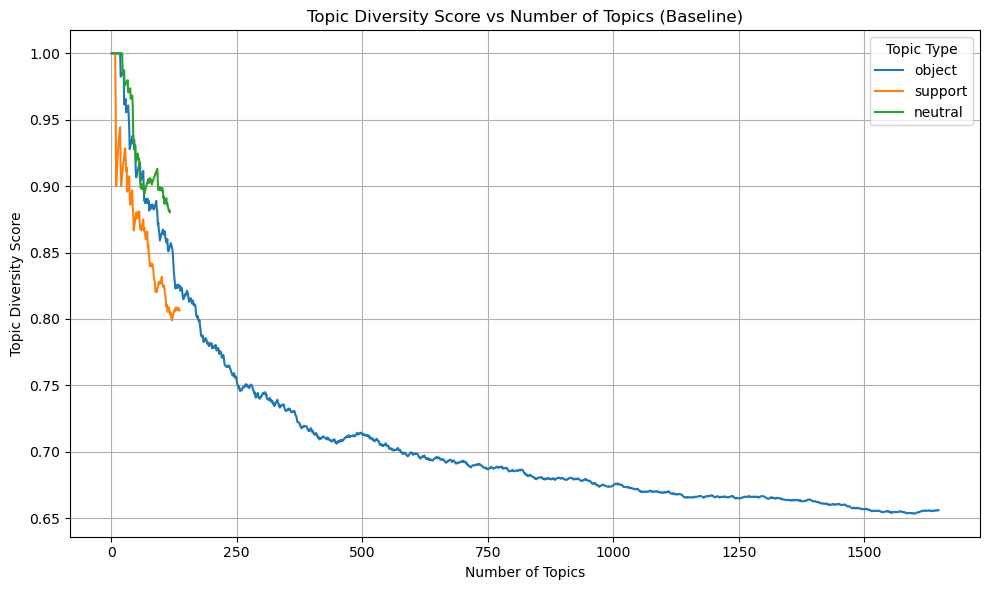

In [ ]:
# plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_all_baseline, x='num_topics', y='diversity_score', hue='topic_type')
plt.title('Topic Diversity Score vs Number of Topics (Baseline)')
plt.xlabel('Number of Topics')
plt.ylabel('Topic Diversity Score')
plt.grid(True)
plt.legend(title='Topic Type')
plt.tight_layout()
plt.show()